# Cluster Analysis

In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import scipy.cluster.hierarchy as hierarchy
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score
import sys

# python source path
sys.path.append('../Src/')
# Set seed
SEED = 1776

# custom python 
import zscore_anomaly
import hierarchy_clustering as hc
import utils
import plot

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Scipy": scipy.__version__,
    "Seaborn": sns.__version__, 
    "Matplot": plt.matplotlib.__version__,
    
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
# Remove scientific notation
np.set_printoptions(suppress=True, precision=4, linewidth=100)
# reset options
# pd.reset_option('display.max_columns')

# Use a single Arrow string & int64 type instance to save memory
arrow_string = pd.ArrowDtype(pa.string())
arrow_int64 = pd.ArrowDtype(pa.int64())

   Library Version
0   Python  3.13.9
1   Pandas   2.3.3
2    NumPy   2.3.4
3    Scipy  1.16.3
4  Seaborn  0.13.2
5  Matplot  3.10.7


In [2]:
# Read Arrow IPC file
with open('../Data/crime_data.arrow', 'rb') as f:
    reader = ipc.open_file(f)
    table = reader.read_all()
    
# Convert back to pandas (Arrow‑backed)
df = table.to_pandas(types_mapper=pd.ArrowDtype)
# Display
df.head()

,date,block,description,location_description,arrest,domestic,beat,district,ward,community_code,year,zip_code,zip_code_area,neighborhood,neighborhood_area,community_name,community_area,x_coordinate,y_coordinate,month,day_of_week,quarter,year_quarter,time_of_day,fbi_code_desc,fbi_index_code,district_location,sector
0,2001-12-30 02:30:00,073XX S YATES BLVD,AUTOMOBILE,STREET,False,False,334,003,07,43,2001,60649,80526075.8505,South Shore,81812716.3904,South Shore,81812716.3958,1193522,1856599,December,Sunday,Q4,2001-Q4,Late Night,Motor Vehicle Theft,True,Grand Crossing,1
1,2001-12-24 12:30:00,045XX N CLARENDON AVE,FRAUD OR CONFIDENCE GAME,APARTMENT,False,False,2313,019,46,03,2001,60640,77305245.6358,Uptown,65095642.836,Uptown,65095642.7289,1170047,1930657,December,Monday,Q4,2001-Q4,Afternoon,Fraud,False,Town Hall,3
2,2001-12-23 22:30:00,028XX W 19TH ST,AUTOMOBILE,STREET,False,False,1022,010,12,30,2001,60623,155285530.844,Little Village,127998297.819,South Lawndale,127998297.867,1157180,1890538,December,Sunday,Q4,2001-Q4,Night,Motor Vehicle Theft,True,Ogden,4
3,2001-12-23 02:30:00,026XX W CHICAGO AVE,AUTOMOBILE,STREET,False,False,1311,012,26,24,2001,60622,70853834.1569,Ukrainian Village,10622385.5776,West Town,127562904.597,1158919,1905276,December,Sunday,Q4,2001-Q4,Late Night,Motor Vehicle Theft,True,Near West,3
4,2001-12-27 19:00:00,031XX N MILWAUKEE AVE,"TRUCK, BUS, MOTOR HOME",OTHER,False,False,2523,025,31,21,2001,60618,141235867.463,Avondale,55290595.482,Avondale,55290595.473,1150039,1920959,December,Thursday,Q4,2001-Q4,Evening,Motor Vehicle Theft,True,Grand Central,5


In [3]:
# NaNs
utils.any_nans(df)

--- Missing Values Found (Total Rows: 8,469,872) ---
                       Count Percentage
neighborhood_area     116237    1.3724%
community_area        116237    1.3724%
zip_code_area         116181    1.3717%
x_coordinate           94303    1.1134%
y_coordinate           94303    1.1134%
ward                   84100    0.9929%
location_description   15338    0.1811%
community_code          9744    0.1150%
zip_code                9744    0.1150%
neighborhood            9744    0.1150%
community_name          9744    0.1150%
district                 139    0.0016%
district_location        139    0.0016%
sector                   139    0.0016%


#### Calculating the Z-score highlights specialized anomalies
- A Z-score of 3.0
    - The value is higher than about 99.87% of all values in a normal distribution 
    - It’s an extreme outlier
- A Z‑score of 2 means:
    - The value is higher than about 97.7% of all values in a normal distribution
    - That year’s count is significantly higher than the historical average
- A Z-score of -1:
    - The value is lower than about 84% of all values
    - It’s a mild decrease, not extreme

##### User Function(s)

In [4]:
def heat_map(data: pd.DataFrame, typ: str='Indexed', figsize: tuple=(16, 6)) -> None:
    # Create the Heatmap
    plt.figure(figsize=figsize)
    sns. heatmap(
        data,
        cmap="RdBu_r",          # Red for high Z-scores, Blue for low
        center=0,               # White represents the mean
        annot=True,             # Change to False if you don't want to see the numbers
        fmt=".2f",              # format as integers
        annot_kws={"size": 8}, # change font size here
        linewidths=.5
    )
    plt.title(f"Z‑Score Heatmap ({typ} Crimes)", fontsize=16)
    plt.xlabel("Year", fontsize=10)
    plt.ylabel("Crime Type", fontsize=12)
    plt.yticks(fontsize=10, rotation=0, ha='right')
    plt.xticks(fontsize=10, rotation=45, ha='right')
    plt.show()

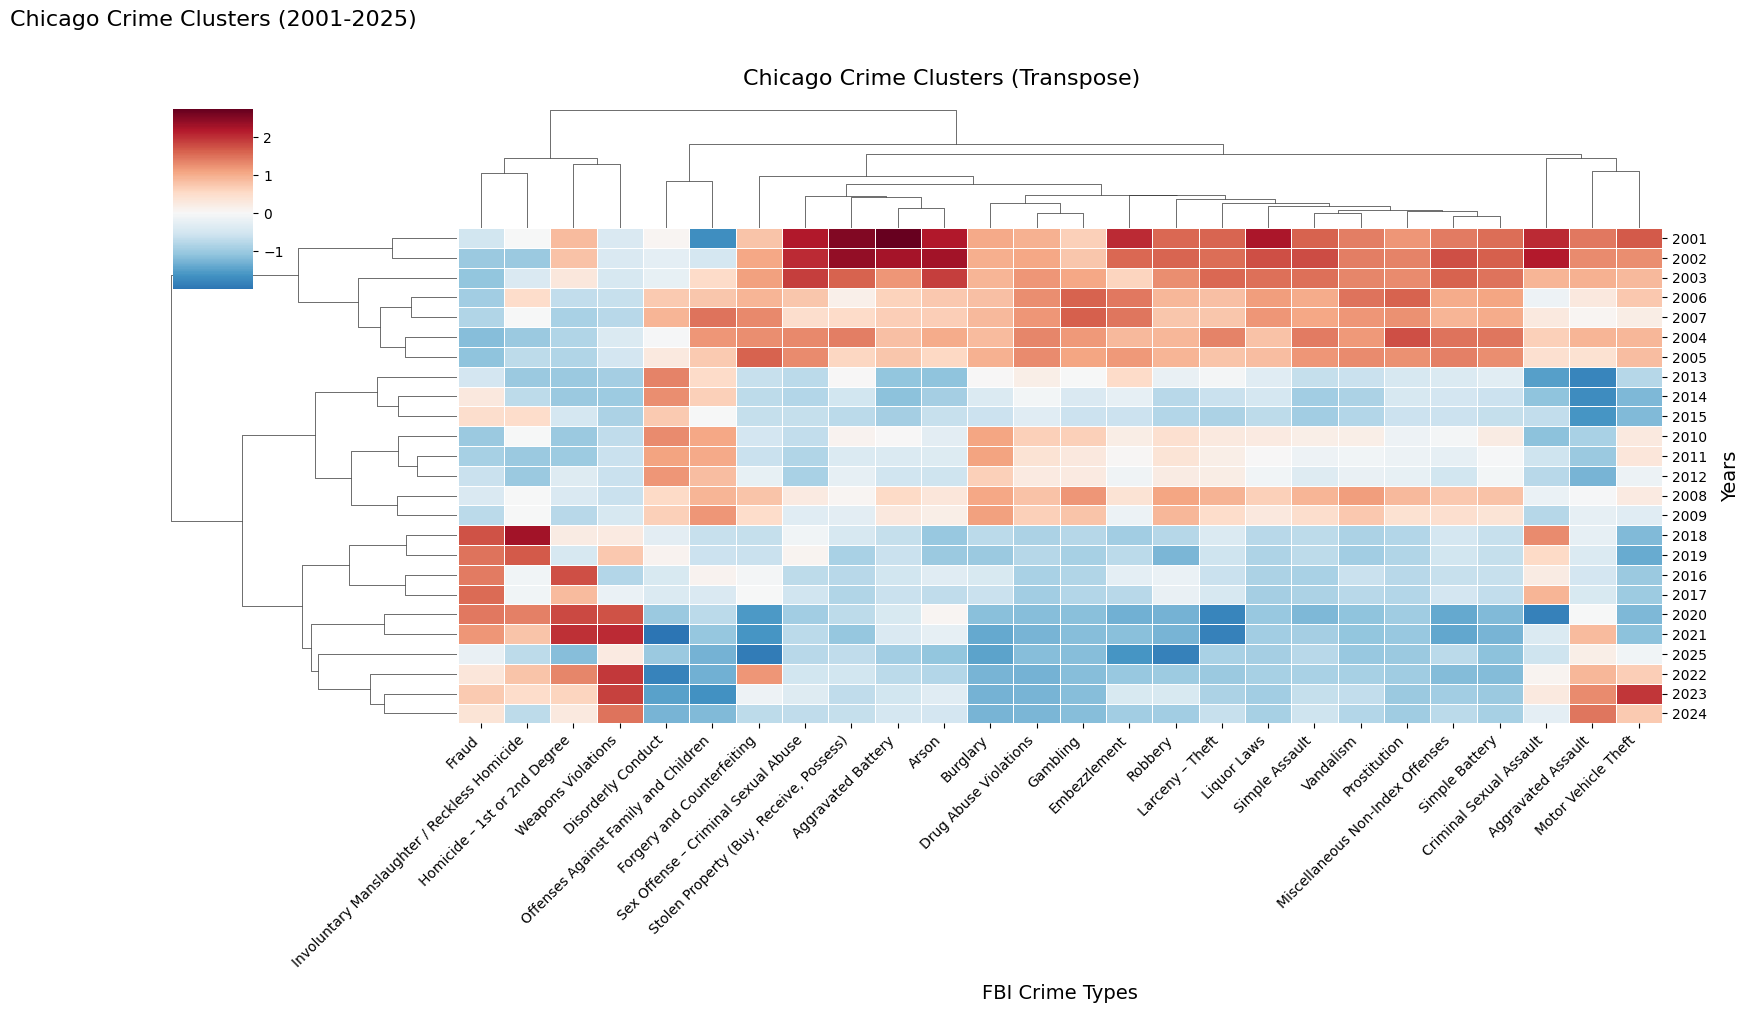

In [5]:
# Z score (Indexed & Non-Indexed
z_df = zscore_anomaly.zscore_anomaly(data=df, time_col='year', category_col='fbi_code_desc')

# Create the clustermap
g = sns.clustermap(
    z_df.T, 
    cmap="RdBu_r", 
    center=0, 
    figsize=(16, 10),
    # row_cluster=True,  # Keep years in chronological order (on the Y-axis)
    col_cluster=True,  # Cluster the crimes together (on the X-axis)
    linewidths=0.5,
    xticklabels=True,   # Ensure all crime names show up
    yticklabels=True    # Ensure all years show up
)

# Rotate X-axis labels for readability
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.title("Chicago Crime Clusters (2001-2025)", fontsize=16, pad=60)
plt.suptitle("Chicago Crime Clusters (Transpose)", fontsize=16, y=1.02)
g.ax_heatmap.set_xlabel('FBI Crime Types', fontsize=14, labelpad=10)
g.ax_heatmap.set_ylabel('Years', fontsize=14, labelpad=10)

# Save the figure with high resolution and tight cropping
plt.savefig("../Image/cluster_Heatmap_analysis.png", dpi=1200, bbox_inches='tight')
plt.show()

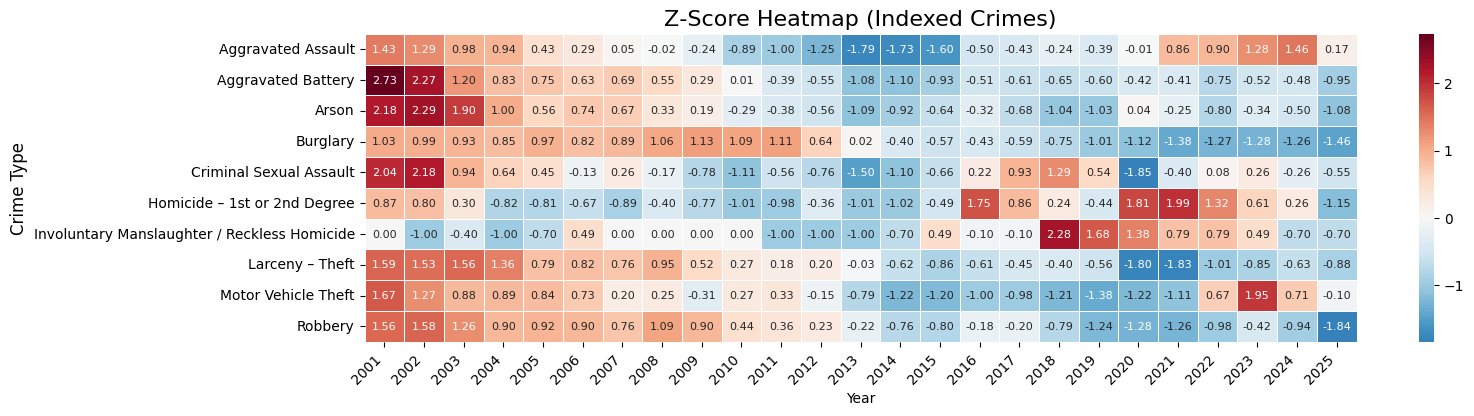

In [6]:
# Calculate z-scores Indexed Crime
mask = df.fbi_index_code == True
z_df_i = zscore_anomaly.zscore_anomaly(data=df[mask], time_col='year', category_col='fbi_code_desc')
# plot
heat_map(z_df_i, 'Indexed', (16,4))

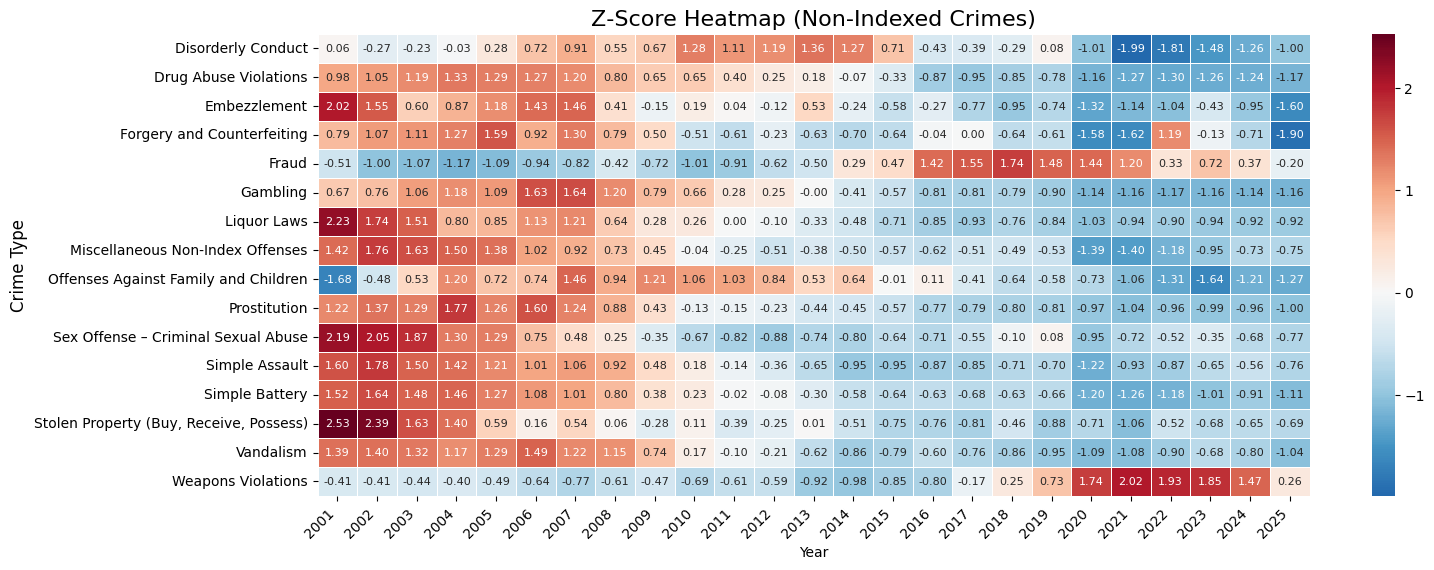

In [7]:
# Calculate z-scores Non-Indexed Crime
mask = df.fbi_index_code == False
z_df_n = zscore_anomaly.zscore_anomaly(data=df[mask],time_col='year', category_col='fbi_code_desc')
heat_map(z_df_n, 'Non-Indexed')

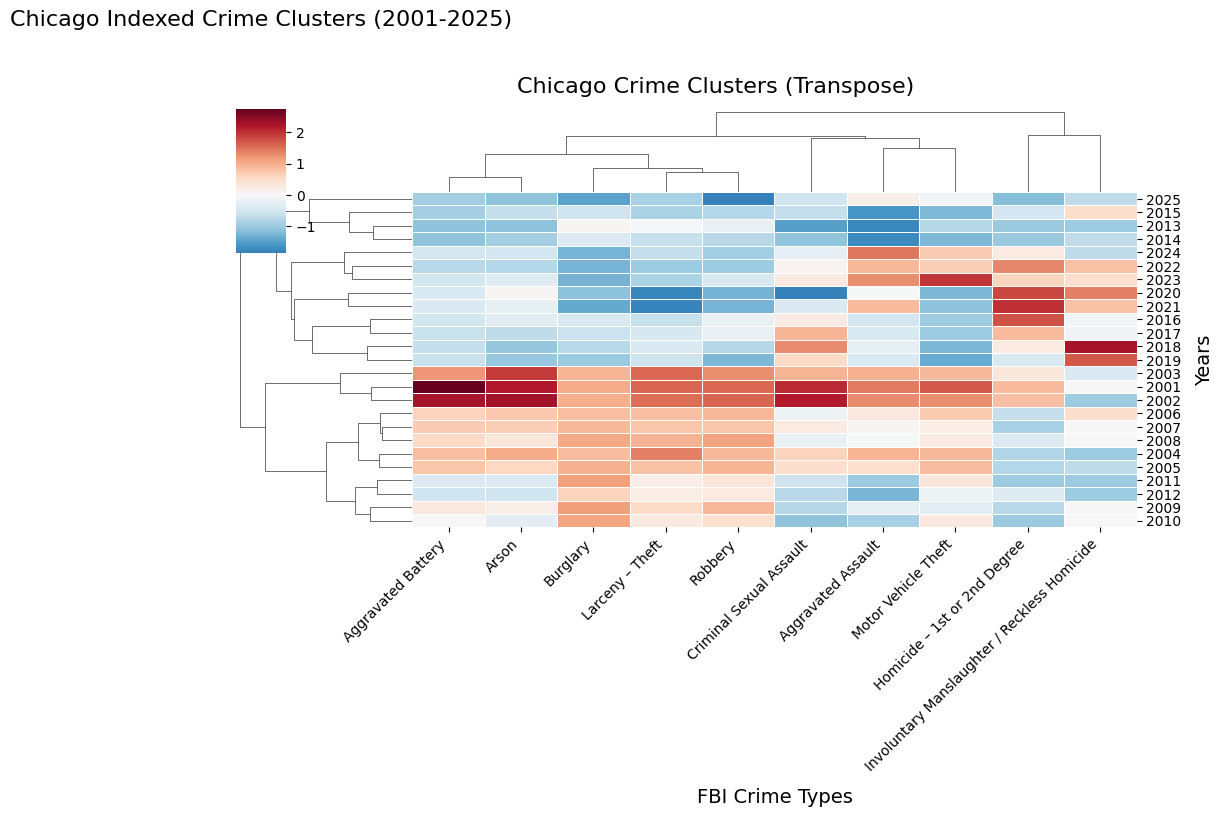

In [8]:
# Z score (Indexed)
# Create the clustermap
g = sns.clustermap(
    z_df_i.T, 
    cmap="RdBu_r", 
    center=0, 
    figsize=(10, 8),
    # row_cluster=True,  # Keep years in chronological order (on the Y-axis)
    col_cluster=True,  # Cluster the crimes together (on the X-axis)
    linewidths=0.5,
    xticklabels=True,   # Ensure all crime names show up
    yticklabels=True    # Ensure all years show up
)

# Rotate X-axis labels for readability
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.title("Chicago Indexed Crime Clusters (2001-2025)", fontsize=16, pad=60)
plt.suptitle("Chicago Crime Clusters (Transpose)", fontsize=16, y=1.02)
g.ax_heatmap.set_xlabel('FBI Crime Types', fontsize=14, labelpad=10)
g.ax_heatmap.set_ylabel('Years', fontsize=14, labelpad=10)

# Save the figure with high resolution and tight cropping
plt.savefig("../Image/cluster_index_analysis.png", dpi=1200, bbox_inches='tight')
plt.show()

**Note:**
1. The Color Intensity (The Values)
* Since you are using Z-scores, look at the color first:
  - Deep Red: The crime count for that specific year was significantly above its historical average.
    - Deep Blue: The crime count for that specific year was significantly below its historical average.
    - White/Light Colors: The crime count was "normal" or very close to the 25-year mean.

2. The Dendrogram (The "Tree" Structure)
* The branches on the top (or side) tell you how similar items are.
* Close Neighbors: If two crime types are connected by a short "U-shaped" branch, they have very similar patterns over the 25-year period.
* Branch Length: The longer the vertical lines of the branch before they join, the less similar those two groups are.

3. Reading the "Clusters" (The Groups)
*  The "Legacy" Cluster: Crimes that were rampant in the early 2000s but have since crashed (like Drug Abuse Violations or Prostitution). These will be Red on the top-left and deep Blue on the bottom-right.
* The "Resilient" Cluster: Crimes that have stayed consistently high or "Red" for almost the entire 25 years. These are the persistent issues Chicago faces.
* The "Modern Surge" Cluster: Crimes that were blue for years but have recently turned bright Red (like Motor Vehicle Theft and Weapons Violations).

4. Reading the X and Y Axis Together
* To find a specific "Anomaly," look for a single "pop" of color that breaks a trend.
* Vertical Red Streaks: If you see a vertical column of red across many crimes for a single year (like 2020), it suggests an External Event (like the Pandemic or civil unrest) affected almost everything at once.
* Horizontal Red Streaks: If one crime type is red across many years, it shows a long-term sustained increase for that specific category.

5. Why the "Rotation" Helps
* By rotating the plot, you can now scan horizontally to see which crimes behave similarly in the same year, and scan vertically to see how a single crime's "fortune" has changed from 2001 to 2025.

**Tip: The "Pivot Point"**
* Look for where the colors flip from Blue to Red. In Chicago's data, there is often a "pivot" around 2016 and 2020. These are the years where the "old" patterns of crime significantly shifted into the "modern" patterns we see today.

### Clustering

In [9]:
# Display Indexed Crimes ONLY
z_df_i.head()

year,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
fbi_code_desc,,,,,,,,,,,,,,,,,,,,,,,,,
Aggravated Assault,1.426698,1.291884,0.980297,0.943692,0.428545,0.288375,0.054461,-0.021427,-0.244628,-0.889231,-0.997260,-1.250816,-1.790961,-1.729357,-1.601687,-0.500862,-0.429438,-0.242842,-0.386583,-0.008035,0.864232,0.899052,1.284742,1.456160,0.174989
Aggravated Battery,2.734977,2.265772,1.203024,0.832353,0.753761,0.627858,0.685336,0.548875,0.289640,0.012027,-0.390706,-0.545935,-1.082001,-1.104288,-0.931856,-0.514655,-0.608496,-0.651897,-0.603412,-0.422769,-0.411821,-0.745347,-0.515437,-0.477509,-0.947496
Arson,2.182703,2.288885,1.899550,1.004585,0.564687,0.741658,0.670870,0.327041,0.185465,-0.289827,-0.380840,-0.557811,-1.088722,-0.921864,-0.638712,-0.320165,-0.684218,-1.043215,-1.028046,0.043889,-0.249377,-0.795457,-0.335334,-0.497135,-1.078609
Burglary,1.034278,0.985417,0.927185,0.853082,0.970422,0.823091,0.889821,1.059770,1.128375,1.085263,1.110005,0.638146,0.019579,-0.395922,-0.568996,-0.430912,-0.591864,-0.748568,-1.011990,-1.121957,-1.384129,-1.267414,-1.281035,-1.260041,-1.461606
Criminal Sexual Assault,2.036762,2.178314,0.938319,0.638229,0.445719,-0.131813,0.264532,-0.165786,-0.782952,-1.105690,-0.562131,-0.760304,-1.496374,-1.100028,-0.664048,0.224898,0.926995,1.289368,0.541974,-1.847422,-0.397931,0.077684,0.264532,-0.262041,-0.550807


### Hierarchical Clustering Linkage Methods
* In hierarchical clustering, choosing the right linkage method is just as important as choosing the distance metric (like Euclidean or Manhattan). The linkage determines the "shape" of the clusters and the algorithm's sensitivity to outliers. These linkage methods work in practice; we need to examine the step-by-step logic of the Agglomerative (Bottom-Up) algorithm. This is the most common way hierarchical clustering is implemented.
* Agglomerative (Bottom-Up) Hierarchical Clustering is a widely used unsupervised machine learning algorithm that builds a nested hierarchy of clusters by iteratively merging the closest pairs of data points. Unlike k-means, it does not require specifying the number of clusters in advance, and the results are often visualized as a dendrogram. 
* `Linkage method choice:` The choice of linkage method in hierarchical clustering is a foundational decision that directly dictates how distances between clusters are calculated, which subsequently defines the structure and quality of the final clustering. 
    * cluster shape
    * sensitivity to noise
    * chaining vs. compactness
    * dendrogram height structure
    * number of clusters detected
#### 1. Specifying the Linkage Criterion: Linkage methods dictate how the algorithm decides which clusters to merge at each step.
[scipy.cluster.hierarchy.linkage](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html)

#### 2. Specifying the Distance Metric: The distance metric defines the "proximity" between two single observations in your dataset.
[scipy.spatial.distance.cdist](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cdist.html)

##### Note:
* Distance = 0: This implies $r = 1$. The two categories are perfectly positively correlated. 
* Distance = 1: This implies $r = 0$. There is no linear relationship at all. These categories provide completely independent information.
* Distance = 2: This implies $r = -1$. They are perfectly negatively correlated. When one category spikes in Z-score, the other drops significantly.

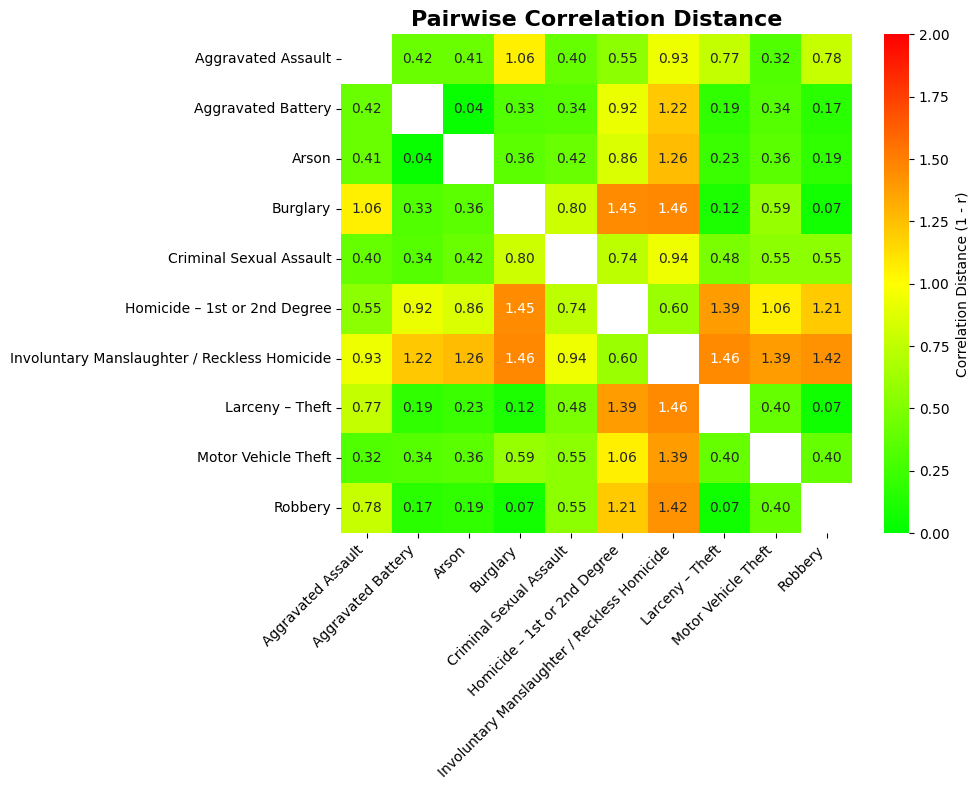

In [10]:
# Indexed Crimes - ONLY
plot.correlation_heatmap(z_df_i, figsize=(10,8))

### Determine Number of Clusters

In [11]:
# Initialize Linkage variable
methods = ['single', 'complete', 'average']
metric = 'correlation'
# Initialize Dict
corr_metric = {}
corr_metric[metric] = {}

for method in methods:
    # Linkage Matrix
    Z_matrix = hc.linkage_matrix(z_df_i, method, metric)
    # Linkage Matrix & Inconsistency coefficient matrix
    clusterI, I = hc.choose_clusters_from_inconsistency(Z_matrix, method, metric)
    clusterL = hc.choose_clusters_from_linkage(Z_matrix, method, metric)
    # Update Dict with Linkage Matrix
    corr_metric[metric][method] = {
    "linkage_matrix": Z_matrix,
    "inconsistency_coeff": I,
    "clusters_inconsistency": clusterI,
    "clusters_linkage": clusterL
    }

----- Using Inconsistency coefficient Matrix ------
Method: single, Metric: correlation, Depth: 2
Estimated number of clusters:  5
Jump occurred at merge index 4

----- Using Linkage Matrix -----
Method: single, Metric: correlation
Estimated number of clusters: 3
Jump at merge index: 6

----- Using Inconsistency coefficient Matrix ------
Method: complete, Metric: correlation, Depth: 2
Estimated number of clusters:  6
Jump occurred at merge index 3

----- Using Linkage Matrix -----
Method: complete, Metric: correlation
Estimated number of clusters: 3
Jump at merge index: 6

----- Using Inconsistency coefficient Matrix ------
Method: average, Metric: correlation, Depth: 2
Estimated number of clusters:  5
Jump occurred at merge index 4

----- Using Linkage Matrix -----
Method: average, Metric: correlation
Estimated number of clusters: 5
Jump at merge index: 4



**Note:**
- Method: average, Metric: correlation, Depth: 2
    - Inconsistency: 5 Clusters
- Method: average, Metric: correlation
    -  Linkage: 5 Clusters

In [12]:
# Initialize Linkage variable
methods = ['ward', 'single', 'complete', 'average', 'median', 'centroid']
metric = 'euclidean'
# Initialize Dict
eucl_metric = {}
eucl_metric[metric] = {}

for method in methods:
    # Linkage Matrix
    Z_matrix = hc.linkage_matrix(z_df_i, method, metric)
    # Linkage Matrix & Inconsistency coefficient matrix
    clusterI, I = hc.choose_clusters_from_inconsistency(Z_matrix, method, metric)
    clusterL = hc.choose_clusters_from_linkage(Z_matrix, method, metric)
    # Update Dict with Linkage Matrix
    eucl_metric[metric][method] = {
    "linkage_matrix": Z_matrix,
    "inconsistency_coeff": I,
    "clusters_inconsistency": clusterI,
    "clusters_linkage": clusterL
    }

----- Using Inconsistency coefficient Matrix ------
Method: ward, Metric: euclidean, Depth: 2
Estimated number of clusters:  4
Jump occurred at merge index 5

----- Using Linkage Matrix -----
Method: ward, Metric: euclidean
Estimated number of clusters: 3
Jump at merge index: 6

----- Using Inconsistency coefficient Matrix ------
Method: single, Metric: euclidean, Depth: 2
Estimated number of clusters:  8
Jump occurred at merge index 1

----- Using Linkage Matrix -----
Method: single, Metric: euclidean
Estimated number of clusters: 6
Jump at merge index: 3

----- Using Inconsistency coefficient Matrix ------
Method: complete, Metric: euclidean, Depth: 2
Estimated number of clusters:  6
Jump occurred at merge index 3

----- Using Linkage Matrix -----
Method: complete, Metric: euclidean
Estimated number of clusters: 3
Jump at merge index: 6

----- Using Inconsistency coefficient Matrix ------
Method: average, Metric: euclidean, Depth: 2
Estimated number of clusters:  8
Jump occurred at m

**Note:**
- Metric: euclidean
    - There is no clear cut consistance in clusters.

### Silhouette Score
**Silhouette score for hierarchical clustering on standardized temporal profiles:**
- 0.20–0.30 $\rightarrow$ weak but usable
- 0.30–0.40 $\rightarrow$ moderate, interpretable structure
- 0.40+ $\rightarrow$ strong, rarely seen in noisy real‑world time series

In [13]:
# make copy
data = z_df_i.copy()
# combined dicts
combined_dict = corr_metric | eucl_metric

# Initialize Cluster Configs
cluster_configs = []
# iterate
for distance_metric, methods in combined_dict.items():
    for linkage_method, results in methods.items():
        cluster_configs.append({
            "metric": distance_metric,
            "method": linkage_method,
            "Z": results["linkage_matrix"],
            "clusters_incon": results["clusters_inconsistency"],
            "clusters_link": results["clusters_linkage"],
            "clusters": {results["clusters_inconsistency"],
                         results["clusters_linkage"]
                        }
        })

In [14]:
# Initialize 
cluster_metrics = []
c_ = []

# Iterate cluster_configs
for cluster_config in cluster_configs:
    # Initialize variable
    method, metric, clusters = (cluster_config['method'], 
                                cluster_config['metric'],
                                cluster_config['clusters']
                               )
    # Iterate Clusters
    for cluster in clusters:
        # Linkage Matrix
        Z = hc.linkage_matrix(data=data, method=method, metric=metric)
        
        # Form clusters
        cluster_info = hierarchy.fcluster(Z, t=cluster, criterion='maxclust')

        # Silhouette metric consistency
        sil_score = silhouette_score(data, cluster_info, metric=metric)

        # Zip fbi_code_desc and cluster_id together
        paired = list(zip(data.index, cluster_info))

        # Sort by cluster_id
        paired_sorted = sorted(paired, key=lambda x: x[1])
        
        # Unzip back into separate lists
        fbi_code_desc_sorted, cluster_id_sorted = zip(*paired_sorted)
        
        # Append
        cluster_metrics.append({
            'cluster': cluster,
            'metric': metric,
            'method': method,
            'silhouette': sil_score,
            'cluster_info': fbi_code_desc_sorted,
            'cluster_id': cluster_id_sorted,
            'Z': Z
        })

        # crime_groups = pd.DataFrame({
        #     '':
        #     'fbi_code_desc': data.index,
        #     'cluster_id': cluster_info
        # }).sort_values('cluster_id')
# Display the top 5 best silhouette scores
df_ = pd.DataFrame(cluster_metrics).sort_values('silhouette', ascending=False).reset_index(drop=True)

In [15]:
df_.head(3)

,cluster,metric,method,silhouette,cluster_info,cluster_id,Z
0,3,correlation,complete,0.441132,"(Homicide – 1st or 2nd Degree, Involuntary Manslaughter / Reckless Homicide, Aggravated Assault, Criminal Sexual Assault, Motor Vehicle Theft, Aggravated Battery, Arson, Burglary, Larceny – Theft, Robbery)","(1, 1, 2, 2, 2, 3, 3, 3, 3, 3)","[[2.0, 1.0, 0.03778377211955064, 2.0], [7.0, 9.0, 0.06847786488894536, 2.0], [11.0, 3.0, 0.11626599201849219, 3.0], [0.0, 8.0, 0.31782114368728487, 2.0], [10.0, 12.0, 0.3601179346422889, 5.0], [4.0, 13.0, 0.5531275048371068, 3.0], [6.0, 5.0, 0.6020540212640992, 2.0], [15.0, 14.0, 1.0609887112009682, 8.0], [16.0, 17.0, 1.4642166331530888, 10.0]]"
1,3,correlation,single,0.439946,"(Aggravated Assault, Aggravated Battery, Arson, Burglary, Criminal Sexual Assault, Larceny – Theft, Motor Vehicle Theft, Robbery, Homicide – 1st or 2nd Degree, Involuntary Manslaughter / Reckless Homicide)","(1, 1, 1, 1, 1, 1, 1, 1, 2, 3)","[[2.0, 1.0, 0.03778377211955064, 2.0], [7.0, 9.0, 0.06847786488894536, 2.0], [11.0, 3.0, 0.07446484611685511, 3.0], [10.0, 12.0, 0.16892776662414533, 5.0], [8.0, 0.0, 0.31782114368728487, 2.0], [4.0, 13.0, 0.3372016998539349, 6.0], [14.0, 15.0, 0.3435851172086698, 8.0], [5.0, 16.0, 0.5487999580925067, 9.0], [6.0, 17.0, 0.6020540212640992, 10.0]]"
2,6,correlation,complete,0.388042,"(Involuntary Manslaughter / Reckless Homicide, Homicide – 1st or 2nd Degree, Aggravated Assault, Motor Vehicle Theft, Criminal Sexual Assault, Aggravated Battery, Arson, Burglary, Larceny – Theft, Robbery)","(1, 2, 3, 3, 4, 5, 5, 6, 6, 6)","[[2.0, 1.0, 0.03778377211955064, 2.0], [7.0, 9.0, 0.06847786488894536, 2.0], [11.0, 3.0, 0.11626599201849219, 3.0], [0.0, 8.0, 0.31782114368728487, 2.0], [10.0, 12.0, 0.3601179346422889, 5.0], [4.0, 13.0, 0.5531275048371068, 3.0], [6.0, 5.0, 0.6020540212640992, 2.0], [15.0, 14.0, 1.0609887112009682, 8.0], [16.0, 17.0, 1.4642166331530888, 10.0]]"


In [16]:
# Initialize Variables
cluster, metric, method, linkage = df_.loc[0, ['cluster', 'metric', 'method', 'Z']]

# Cluster with Best silhouette score
clusters = hierarchy.fcluster(linkage, t=cluster, criterion='maxclust')

# Create the mapping using .columns instead of .index
# This matches the names on the X-axis of your rotated plot
crime_groups = pd.DataFrame({
    'fbi_code_desc': data.index, 
    'cluster_id': clusters
}).sort_values('cluster_id')

# Display the members
for cluster_num in range(1, (len(np.unique(clusters))) + 1):
    members = crime_groups[crime_groups['cluster_id'] == cluster_num]['fbi_code_desc'].tolist()
    print(f"--- Cluster {cluster_num}  ---")
    print("\n".join([f"  • {m}" for m in members]))
    print("-" * 30)

--- Cluster 1  ---
  • Homicide – 1st or 2nd Degree
  • Involuntary Manslaughter / Reckless Homicide
------------------------------
--- Cluster 2  ---
  • Aggravated Assault
  • Criminal Sexual Assault
  • Motor Vehicle Theft
------------------------------
--- Cluster 3  ---
  • Aggravated Battery
  • Arson
  • Burglary
  • Larceny – Theft
  • Robbery
------------------------------


### Summary (Indexed Crimes) <a id="Indexed"></a>
#### Correlation Distance + Complete Linkage on Z‑Scored Crime Time Series
This analysis examines how indexed crime categories in the dataset move over time by applying hierarchical clustering to **Z‑scored time series** using **correlation distance** and **complete linkage**. This configuration isolates **patterns of co‑movement**, allowing us to identify crime types that rise and fall together relative to their own historical baselines.

#### Key Insight
The resulting clusters do **not** reflect crime volume or severity. Instead, they reveal **synchronized temporal behavior**, crime types that tend to spike, dip, or shift together. These shared patterns often point to common underlying drivers such as environmental conditions, social dynamics, or policy changes.

#### Cluster Findings
##### Cluster 1: Lethal Violence
* Homicide – 1st or 2nd Degree
* Involuntary Manslaughter / Reckless Homicide
    * These offenses show tightly aligned anomaly patterns. When one deviates from its norm, the other typically does as well. This suggests shared situational or behavioral dynamics influencing lethal outcomes.
##### Cluster 2: Interpersonal Violence + Motor Vehicle Theft
* Aggravated Assault
* Criminal Sexual Assault
* Motor Vehicle Theft
    * Despite spanning both violent and property crime, these categories exhibit remarkably similar temporal rhythms. Their co‑movement suggests that broader social or environmental factors may be influencing both interpersonal violence and vehicle theft.
##### Cluster 3: Property Crime + Related Offenses
* Aggravated Battery
* Arson
* Burglary
* Larceny – Theft
* Robbery
    * This larger cluster reflects a group of offenses that share long‑term trends and seasonal patterns. Their synchronized behavior suggests they respond similarly to opportunity structures, economic conditions, or shifts in routine activity patterns.
##### Conclusion
Using Z‑scores with correlation distance and complete linkage reveals meaningful structure in the temporal behavior of crime categories. The clusters represent **coherent groups of crimes that move together over time**, offering valuable insight for forecasting, operational planning, and strategic decision‑making.